In [31]:
import os

#from config import PROJECT_ROOT, DATASETS_DIR

PROJECT_ROOT = "./"

DATASET_FILENAME = "lab1_var6.csv"
TMP_DIR_PATH     = os.path.join(PROJECT_ROOT, "tmp")


In [32]:
import pandas as pd

# 1.1
df = pd.read_csv(DATASET_FILENAME)
# Remove first column because it is useless
df.drop(columns=df.columns[0], inplace=True)

In [33]:

# 1.2
df.head()

,Var1,Var2,Var3,Var4,Var5,Label
0,1050.881652,210.176330,475.128618,285.077171,380.102894,2
1,1051.893048,210.378610,522.030039,313.218023,417.624031,3
2,955.793279,191.158656,527.686331,316.611798,422.149064,1
3,957.499912,191.499982,472.765186,283.659112,378.212149,3
4,1052.415180,210.483036,473.884404,284.330642,379.107523,2


In [34]:
# 1.3
df.describe()

,Var1,Var2,Var3,Var4,Var5,Label
count,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
mean,1000.666976,200.133395,499.930786,299.958471,399.944629,1.470000
std,50.611568,10.122314,26.209528,15.725717,20.967622,1.114233
min,935.197200,187.039440,463.120946,277.872567,370.496756,0.000000
25%,952.596224,190.519245,474.993179,284.995908,379.994544,0.750000
50%,1000.236810,200.047362,500.927552,300.556531,400.742041,1.000000
75%,1051.322453,210.264491,526.136460,315.681876,420.909168,2.000000
max,1068.024766,213.604953,537.603434,322.562060,430.082747,3.000000


In [35]:
# 1.4
df.columns = map(lambda var: var.replace('Var', 'Class'), df.columns)
df

,Class1,Class2,Class3,Class4,Class5,Label
0,1050.881652,210.176330,475.128618,285.077171,380.102894,2
1,1051.893048,210.378610,522.030039,313.218023,417.624031,3
2,955.793279,191.158656,527.686331,316.611798,422.149064,1
3,957.499912,191.499982,472.765186,283.659112,378.212149,3
4,1052.415180,210.483036,473.884404,284.330642,379.107523,2
...,...,...,...,...,...,...
95,974.965156,194.993031,536.296197,321.777718,429.036958,1
96,936.080204,187.216041,518.740542,311.244325,414.992434,2
97,935.573214,187.114643,466.021134,279.612680,372.816907,1
98,1043.606588,208.721318,525.391868,315.235121,420.313494,3


/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:1615: UserWarning: KDE cannot be estimated (0 variance or perfect covariance). Pass `warn_singular=False` to disable this warning.
  func(x=x, y=y, **kwargs)
/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:1615: UserWarning: KDE cannot be estimated (0 variance or perfect covariance). Pass `warn_singular=False` to disable this warning.
  func(x=x, y=y, **kwargs)
/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:1615: UserWarning: KDE cannot be estimated (0 variance or perfect covariance). Pass `warn_singular=False` to disable this warning.
  func(x=x, y=y, **kwargs)
/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:1615: UserWarning: KDE cannot be estimated (0 variance or perfect covariance). Pass `warn_singular=False` to disable this warning.
  func(x=x, y=y, **kwargs)
/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:1615: UserWarning: KDE cannot be estimated (0 variance or perfect co

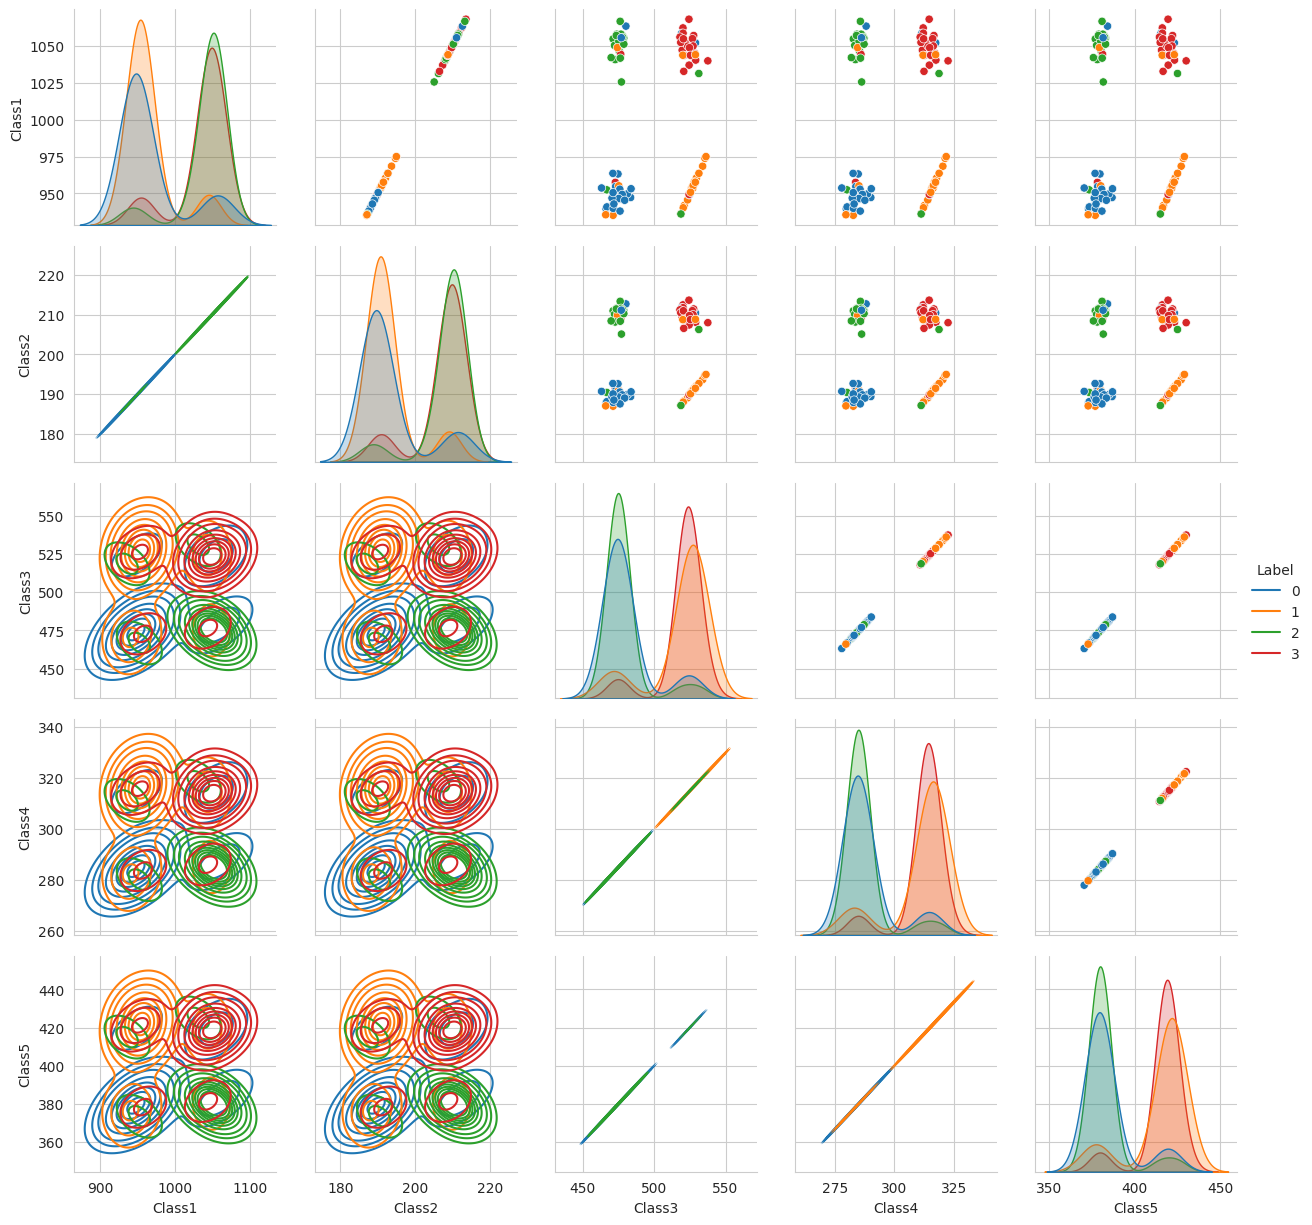

In [36]:
# 1.5

import seaborn as sns

sns.set_style('whitegrid')

g = sns.PairGrid(df, hue='Label', palette='tab10', diag_sharey=False)
g.map_diag(sns.kdeplot, fill=True)
g.map_upper(sns.scatterplot)
g.map_lower(sns.kdeplot)
g.add_legend()

In [37]:
# 1.6.1

import matplotlib.pyplot as plt

from math import floor, ceil
from typing import List


class HistsPlotter:
    def __init__(self,
                 features: List[str],
                 bins_count: int):
        self.features = features
        self.bins_count = bins_count

        self.subplots_width  = floor(len(features)**0.5)
        self.subplots_height = \
            ceil(len(features) / self.subplots_width)

    def plot(self, **kwargs) -> None:
        fig, axs = plt.subplots(
            self.subplots_width,
            self.subplots_height
        )
        axs = axs.flat

        for i, feature in enumerate(self.features):
            sns.histplot(x=feature, bins=self.bins_count, ax=axs[i], **kwargs)

        plt.tight_layout()

hists_plotter = HistsPlotter(
    [c for c in df.columns.tolist() if c != 'Label'],
    30
)

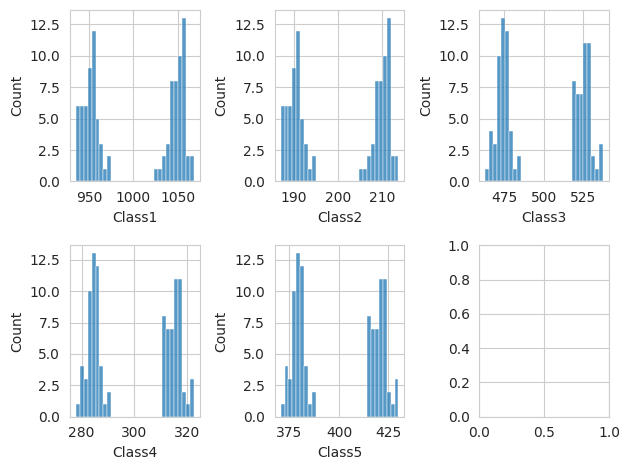

In [38]:
hists_plotter.plot(data=df)

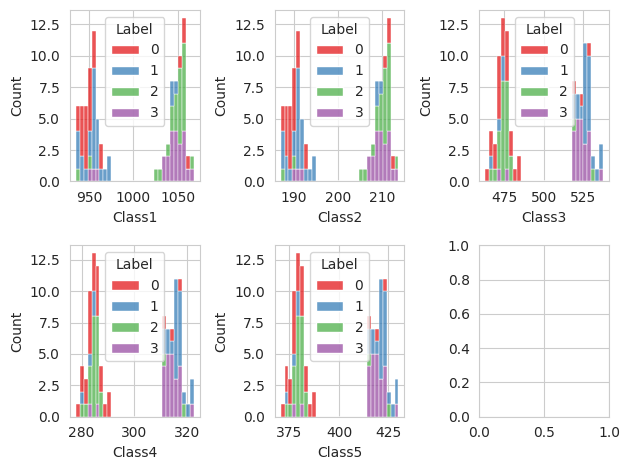

In [39]:
# 1.6.2 stacked

hists_plotter.plot(data=df, hue='Label', multiple='stack', palette='Set1')

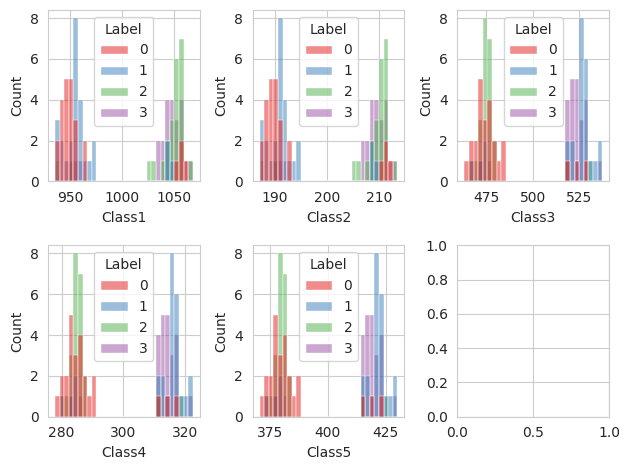

In [40]:
# 1.6.2 crossed

hists_plotter.plot(data=df, hue='Label', multiple='layer', palette='Set1')

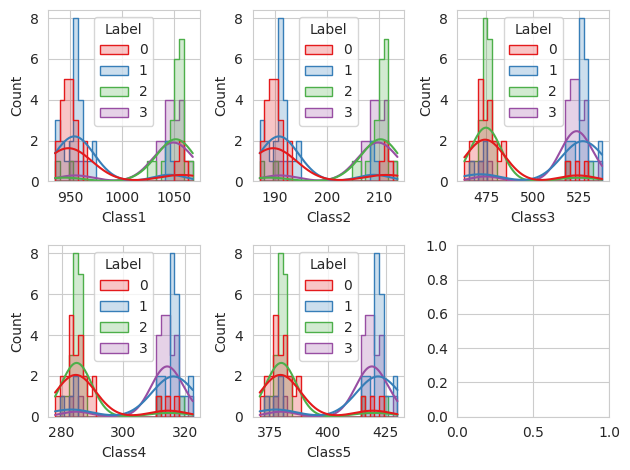

In [41]:
# 1.6.3

hists_plotter.plot(data=df, hue='Label', palette='Set1', element='step',
                   kde=True)

In [42]:
# 2.1

import numpy as np

dataset_data = np.genfromtxt(
    DATASET_FILENAME,
    delimiter=',',
    names=True,
    usecols=range(1, 7)
)
dataset_data

array([(1050.88165215, 210.17633043, 475.12861767, 285.0771706 , 380.10289414, 2.),
       (1051.89304807, 210.37860961, 522.03003906, 313.21802344, 417.62403125, 3.),
       ( 955.79327942, 191.15865588, 527.68633058, 316.61179835, 422.14906446, 1.),
       ( 957.49991226, 191.49998245, 472.76518649, 283.6591119 , 378.2121492 , 3.),
       (1052.41518022, 210.48303604, 473.88440384, 284.33064231, 379.10752308, 2.),
       ( 941.82851075, 188.36570215, 521.02042855, 312.61225713, 416.81634284, 1.),
       ( 945.64161022, 189.12832204, 523.41166558, 314.04699935, 418.72933246, 1.),
       (1062.12094801, 212.4241896 , 520.16995029, 312.10197017, 416.13596023, 3.),
       (1054.71610156, 210.94322031, 473.0722934 , 283.84337604, 378.45783472, 2.),
       ( 952.4301052 , 190.48602104, 466.7723942 , 280.06343652, 373.41791536, 2.),
       (1047.03245928, 209.40649186, 519.61077888, 311.76646733, 415.6886231 , 3.),
       ( 968.45716462, 193.69143292, 533.97345382, 320.38407229, 427.1787630

In [43]:
# 2.2

dataset_data[0:10]

array([(1050.88165215, 210.17633043, 475.12861767, 285.0771706 , 380.10289414, 2.),
       (1051.89304807, 210.37860961, 522.03003906, 313.21802344, 417.62403125, 3.),
       ( 955.79327942, 191.15865588, 527.68633058, 316.61179835, 422.14906446, 1.),
       ( 957.49991226, 191.49998245, 472.76518649, 283.6591119 , 378.2121492 , 3.),
       (1052.41518022, 210.48303604, 473.88440384, 284.33064231, 379.10752308, 2.),
       ( 941.82851075, 188.36570215, 521.02042855, 312.61225713, 416.81634284, 1.),
       ( 945.64161022, 189.12832204, 523.41166558, 314.04699935, 418.72933246, 1.),
       (1062.12094801, 212.4241896 , 520.16995029, 312.10197017, 416.13596023, 3.),
       (1054.71610156, 210.94322031, 473.0722934 , 283.84337604, 378.45783472, 2.),
       ( 952.4301052 , 190.48602104, 466.7723942 , 280.06343652, 373.41791536, 2.)],
      dtype=[('Var1', '<f8'), ('Var2', '<f8'), ('Var3', '<f8'), ('Var4', '<f8'), ('Var5', '<f8'), ('Label', '<f8')])

In [44]:
# 2.3

def numpy_describe(data):
    features = dataset_data.dtype.names

    specs = {
        "count": lambda x: len(x),
        "mean":  lambda x: np.mean(x),
        "std":   lambda x: np.std(x, ddof=1),
        "min":   lambda x: np.min(x),
        "25%":   lambda x: np.quantile(x, 0.25),
        "50%":   lambda x: np.quantile(x, 0.50),
        "75%":   lambda x: np.quantile(x, 0.75),
        "max":   lambda x: np.max(x),
    }

    for name, method in specs.items():
        print(name, end='\t')
        for feature in features:
            print(f"{method(data[feature]):5.4f}", end=' ')
        print()

numpy_describe(dataset_data)

count	100.0000 100.0000 100.0000 100.0000 100.0000 100.0000 
mean	1000.6670 200.1334 499.9308 299.9585 399.9446 1.4700 
std	50.6116 10.1223 26.2095 15.7257 20.9676 1.1142 
min	935.1972 187.0394 463.1209 277.8726 370.4968 0.0000 
25%	952.5962 190.5192 474.9932 284.9959 379.9945 0.7500 
50%	1000.2368 200.0474 500.9276 300.5565 400.7420 1.0000 
75%	1051.3225 210.2645 526.1365 315.6819 420.9092 2.0000 
max	1068.0248 213.6050 537.6034 322.5621 430.0827 3.0000 


In [45]:
# 3.1 label encoder

from sklearn.preprocessing import LabelEncoder

features = df['Label']

label_encoder = LabelEncoder()
label_encoder.fit(features)
print(label_encoder.transform(features)[:5])

[2 3 1 3 2]


In [46]:
# 3.1 one-hot encoder

from sklearn.preprocessing import OneHotEncoder

features = [[feature] for feature in df['Label']]

onehot_encoder = OneHotEncoder(sparse_output=False)
onehot_encoder.fit(features)
print(onehot_encoder.transform(features)[:5])

[[0. 0. 1. 0.]
 [0. 0. 0. 1.]
 [0. 1. 0. 0.]
 [0. 0. 0. 1.]
 [0. 0. 1. 0.]]


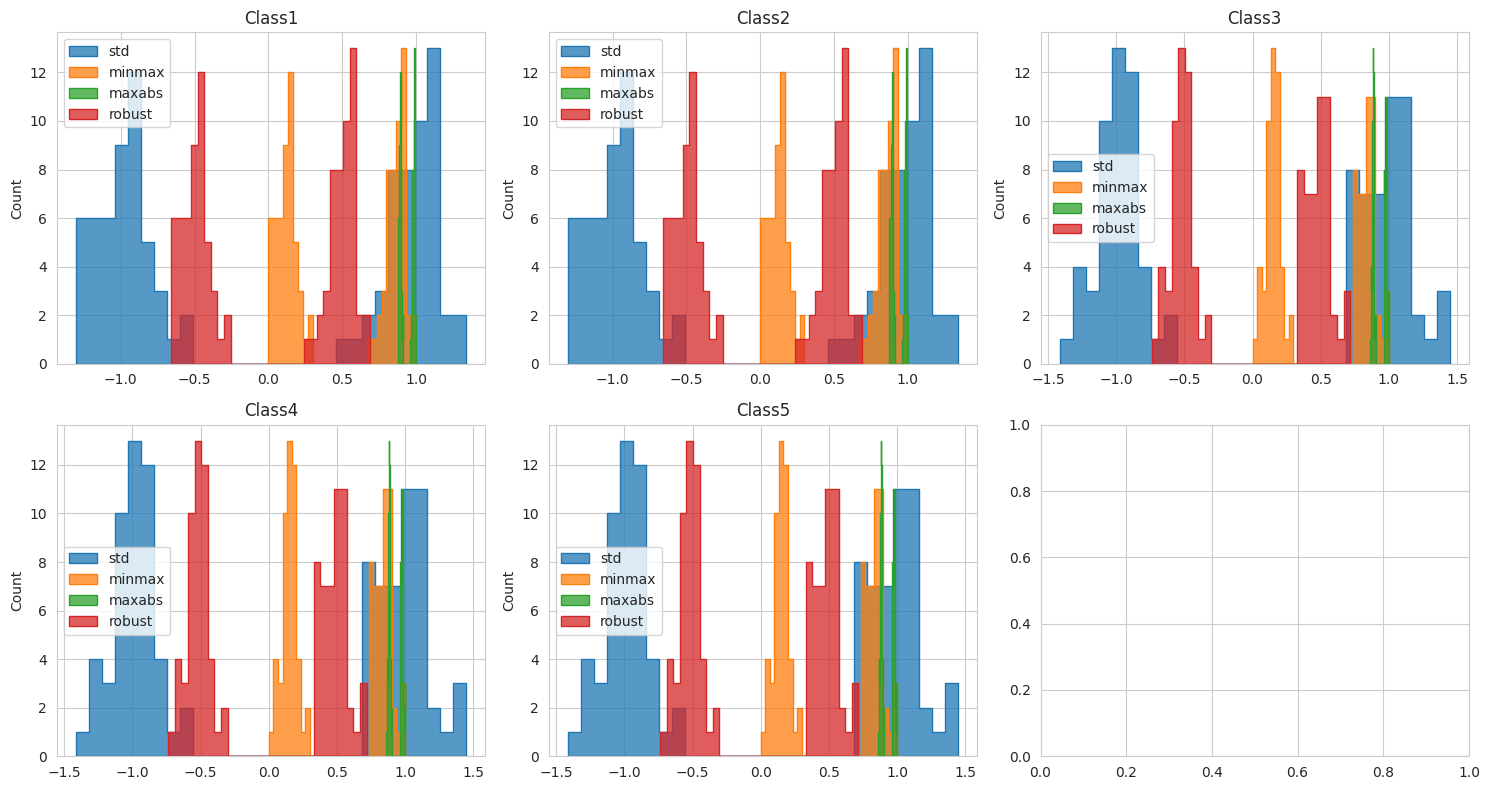

In [47]:
# 3.2

from sklearn.preprocessing import (
    StandardScaler, MinMaxScaler, MaxAbsScaler, RobustScaler
)

features = [feature for feature in df.columns if feature != 'Label']
data = df[features].to_numpy()

subplots_width  = floor(len(features) ** 0.5)
subplots_height = ceil(len(features) / subplots_width)

scalers = {
    "std":    StandardScaler(),
    "minmax": MinMaxScaler(),
    "maxabs": MaxAbsScaler(),
    "robust": RobustScaler()
}

fig, axs = plt.subplots(
    subplots_width,
    subplots_height,
    figsize=(15, 8)
)
axs = axs.flat

bins_count = 30
for i, feature in enumerate(features):
    transformed_data = []
    for name, scaler in scalers.items():
        transformed_data = scaler.fit_transform(data)

        sns.histplot(
            data=transformed_data[:, i],
            label=name,
            bins=bins_count,
            ax=axs[i],
            element='step'
        )
    axs[i].set_title(feature)
    axs[i].legend()

plt.tight_layout()

In [48]:
# 4.1

from sklearn.decomposition import PCA
from sklearn.manifold      import TSNE


for n_components in range(data.shape[1] - 1, 0, -1):
    pca = PCA(n_components=n_components)
    pca.fit(data)
    print(f"pca: n_components={n_components}: {np.sum(pca.explained_variance_ratio_)}")

pca: n_components=4: 1.0
pca: n_components=3: 0.9999999999999998
pca: n_components=2: 0.9999999999999678
pca: n_components=1: 0.6601156802647675


In [49]:
# 4.1


labels = df['Label']

class ReducedPlotter:
    """
    Plots pair of charts for PCA and t-SNE reducers.
    """

    def __init__(self, data, labels):
        self.data = data
        self.labels = labels
        self.colors = sns.color_palette("Set1", len(labels.unique()))

    def plot(self, fig, n_components):
        if n_components not in [1, 2, 3]:
            raise RuntimeError(f"Impossible n_components value: {n_components}")

        ax1, ax2 = __class__._get_axes(fig, n_components)
        ax1.set_title(f"PCA, n_components={n_components}")
        ax2.set_title(f"t-SNE, n_components={n_components}")

        pca  =  PCA(n_components=n_components)
        tsne = TSNE(n_components=n_components, random_state=42)

        reduced_pca = pca.fit_transform(self.data)
        reduced_tsne = tsne.fit_transform(self.data)

        for i, label in enumerate(sorted(self.labels.unique())):
            idx = self.labels == label

            if n_components == 1:
                sns.kdeplot(reduced_pca[idx, 0], color=self.colors[i],
                            label=f"Label {label}", ax=ax1)
                sns.kdeplot(reduced_tsne[idx, 0], color=self.colors[i],
                            label=f"Label {label}", ax=ax2)
            else:
                coords_pca = [reduced_pca[idx, k] for k in range(n_components)]
                ax1.scatter(
                    *coords_pca,
                    color=self.colors[i],
                    label=f"Label {label}",
                    s=50
                )

                coords_tsne = [reduced_tsne[idx, k] for k in range(n_components)]
                ax2.scatter(
                    *coords_tsne,
                    color=self.colors[i],
                    label=f"Label {label}",
                    s=50
                )

        ax1.legend()
        ax2.legend()

        return ax1, ax2

    @staticmethod
    def _get_axes(fig, n_components):
        if n_components in [1, 2]:
            ax1 = fig.add_subplot(121)
            ax2 = fig.add_subplot(122)
        elif n_components == 3:
            ax1 = fig.add_subplot(121, projection="3d")
            ax2 = fig.add_subplot(122, projection="3d")

        return (ax1, ax2)

plotter = ReducedPlotter(data, labels)

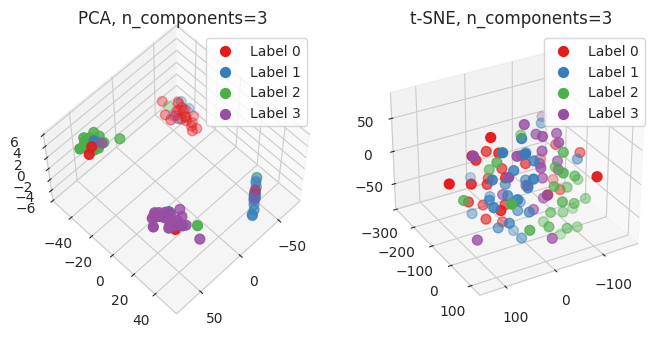

In [53]:
fig = plt.figure(figsize=(8, 15))
ax1, ax2 = plotter.plot(fig, 3)
ax1.view_init(elev=60, azim=45)
ax2.view_init(elev=30, azim=60)
plt.show()

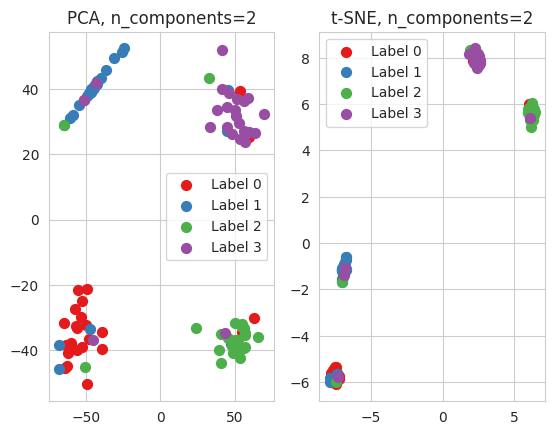

In [51]:
fig = plt.figure()
ax1, ax2 = plotter.plot(fig, 2)
plt.show()

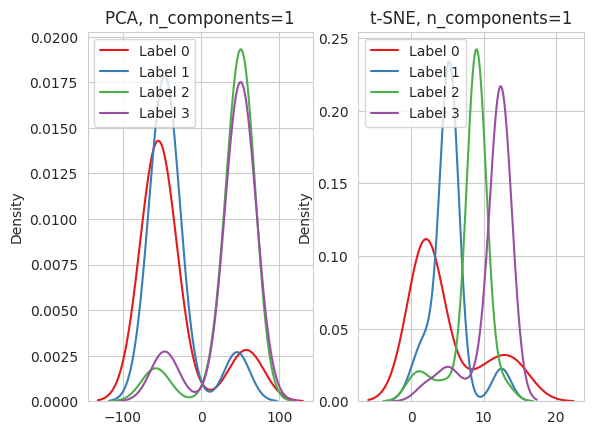

In [52]:
fig = plt.figure()
ax1, ax2 = plotter.plot(fig, 1)
plt.show()